<a href="https://colab.research.google.com/github/arfatkc215-lang/CNN_Based_Edge_Detection/blob/main/CNN_Based_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
image = Image .open("catsample.jpg").convert("L")
image = image.resize((256,256))
image = np.array(image,dtype=np.float32) / 255.0

In [ ]:
image = np.expand_dims(image,axis=(0, -1))


In [ ]:
vertical_filter = np.array([[1,0,-1],
                            [1,0,-1],
                            [1, 0 ,-1]], dtype = np.float32)

In [ ]:
horizontal_filter = np.array([[1, 1, 1],
                              [1 ,0 , 0],
                              [-1 , -1 ,-1]], dtype = np.float32)

In [ ]:
vertical_filter = vertical_filter.reshape(3 ,3, 1 ,1)
horizontal_filter = horizontal_filter.reshape(3 ,3, 1 ,1)

In [ ]:
vertical_edges = tf.nn.conv2d(image, vertical_filter, strides=[1, 1, 1, 1], padding='SAME')
horizontal_edges = tf.nn.conv2d(image, horizontal_filter, strides=[1, 1, 1, 1], padding='SAME')

In [ ]:
vertical_edges = vertical_edges.numpy().squeeze()
horizontal_edges = horizontal_edges.numpy().squeeze()

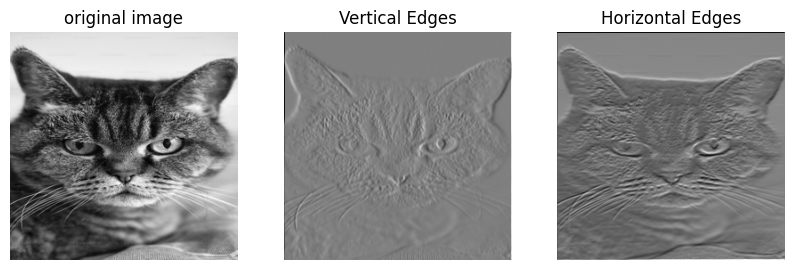

In [ ]:
# Original Image
plt.figure(figsize = (10, 4))
plt.subplot(1, 3, 1)
plt.imshow(image.squeeze(),cmap ="gray")
plt.title("original image")
plt.axis("off")

# Vertical Edges
plt.subplot(1,3,2)
plt.imshow(vertical_edges, cmap="gray")
plt.title("Vertical Edges")
plt.axis("off")

# Horizontal Edges
plt.subplot(1,3,3)
plt.imshow(horizontal_edges, cmap="gray")
plt.title("Horizontal Edges")
plt.axis("off")


plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
image = Image.open("catsample.jpg").convert("L")
image = image.resize((256, 256))
image = np.array(image, dtype=np.float32) / 255.0


In [ ]:
image = np.expand_dims(image, axis=(0, -1))

print(image.shape)

(1, 256, 256, 1)


In [ ]:
blur_filter = np.ones((5,5), dtype=np.float32) / 25

blur_filter = blur_filter.reshape(5,5,1,1)

print(blur_filter.shape)

(5, 5, 1, 1)


In [ ]:
blurred_image = tf.nn.conv2d(
    image,
    blur_filter,
    strides=[1,1,1,1],
    padding='SAME'
)

blurred_image = blurred_image.numpy().squeeze()

print(blurred_image.shape)

(256, 256)


In [ ]:
emboss_filter = np.array([
    [-2,-1,0],
    [-1, 1,1],
    [ 0, 1,2]
], dtype=np.float32)

emboss_filter = emboss_filter.reshape(3,3,1,1)

print(emboss_filter.shape)

(3, 3, 1, 1)


In [ ]:
embossed_image = tf.nn.conv2d(
    image,
    emboss_filter,
    strides=[1,1,1,1],
    padding='SAME'
)

embossed_image = embossed_image.numpy().squeeze()

print(embossed_image.shape)

(256, 256)


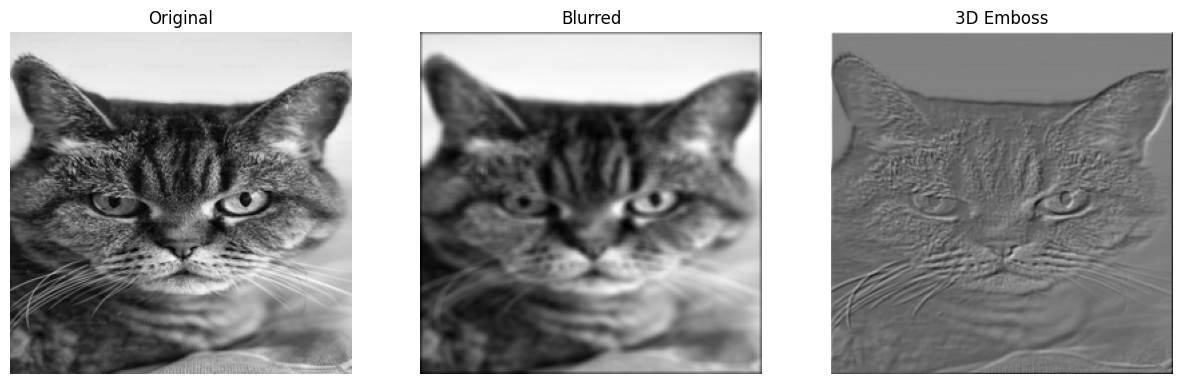

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image.squeeze(), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blurred_image, cmap='gray')
plt.title("Blurred")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(embossed_image, cmap='gray')
plt.title("3D Emboss")
plt.axis('off')

plt.show()